In [9]:
# 1  Imports ------------------------------------------------------
import os, glob, json, random, itertools, copy, math, sys
from collections import Counter, defaultdict

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(r"C:\work projects\ITMO\NIR\external")
sys.path.append(r"C:\work projects\ITMO\NIR\external\codebleu")

from codebleu.my_calc_code_blue import calc_codebleu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_dtype = torch.float16 if device.type == "cuda" else torch.float32


In [10]:
# 0  Constants ----------------------------------------------------
ROOT_CODE = r"C:\work projects\ITMO\NIR\new_exp"  # ← do not change
ROOT_DATA = r"G:\ITMO\NIR\DATASETS\processed"
MODEL_NAME = "bigcode/starcoderbase-1b"           # FP16, GPU
SAMPLE_SIZE = 2                                   # smoke‑run (None → full)
ENSEMBLE_K = 3
POP_SIZE   = 6   # Genetic: population
N_GEN      = 4   # Genetic: generations
RL_STEPS   = 25  # RL hill‑climb


In [11]:
# 2  Helpers: dataset & template ---------------------------------
def load_template(path: str, dataset_name: str):
    with open(path, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)
    return data['datasets'][dataset_name]['template']

def load_datasets(root:str, sample_size=None):
    paths = sorted(glob.glob(os.path.join(root, '*.jsonl')))
    datasets = {}
    for p in paths:
        name = Path(p).stem
        with open(p, 'r', encoding='utf-8') as f:
            lines = [json.loads(l) for l in f]
        if sample_size:
            lines = lines[:sample_size]
        datasets[name] = lines
    return datasets

template = load_template(os.path.join(ROOT_CODE,'baseline_prompt.yaml'), dataset_name="mbpp")
datasets = load_datasets(ROOT_DATA, SAMPLE_SIZE)
print(f"Loaded template and {len(datasets)} datasets")


Loaded template and 4 datasets


In [12]:
# 3  Load StarCoderBase‑1B ---------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    device_map="auto"
).eval()


In [13]:
# 4  Prompt helpers ----------------------------------------------
def fill_template(temp:str, inp:str):
    return temp.format(input=inp)

def majority_vote(seq):
    return Counter(seq).most_common(1)[0][0]


## Prompt optimisation methods

In [18]:
# -- Baseline ------------------------------------------------------
def baseline_prompt(inp:str):
    return fill_template(template, inp)

# -- Chain‑of‑Thought --------------------------------------------
def cot_prompt(inp:str):
    cot_template = 'Думай шаг за шагом. ' + template
    return fill_template(cot_template, inp)

# -- Prompt ensembling -------------------------------------------
ENSEMBLE_TEMPLATES = [
    "Найди ответ: {input}",
    "Ответь на вопрос: {input}",
    "Дано: {input}\nОтвет:"
]
def ensembling_prompt(inp:str):
    prompts = [t.format(input=inp) for t in ENSEMBLE_TEMPLATES]
    return prompts  # list – to be handled in generate


In [14]:
# -- Genetic Prompt Optimisation ----------------------------------
import re

GEN_TOKENS = ["Пожалуйста", "Ответ", "Реши", "Подумай", "Шаги", "Объясни"]
def mutate(prompt:str):
    words = prompt.split()
    if random.random() < 0.5 and len(words)>1:
        # delete
        idx = random.randrange(len(words))
        words.pop(idx)
    else:
        # insert
        idx = random.randrange(len(words)+1)
        words.insert(idx, random.choice(GEN_TOKENS))
    return " ".join(words)

def genetic_search(inp:str):
    # initialise population
    pop = [baseline_prompt(inp) for _ in range(POP_SIZE)]
    best_prompt, best_score = pop[0], -1.0
    for gen in range(N_GEN):
        scored = []
        for pr in pop:
            score = evaluate_prompt_single(inp, pr)['codebleu']
            scored.append((score, pr))
            if score > best_score:
                best_prompt, best_score = pr, score
        # selection
        scored.sort(reverse=True)
        parents = [pr for _, pr in scored[:POP_SIZE//2]]
        # create next population
        pop = parents.copy()
        while len(pop) < POP_SIZE:
            parent = random.choice(parents)
            child  = mutate(parent)
            pop.append(child)
    return best_prompt


In [15]:
# -- RL Prompting (hill‑climb) ------------------------------------
def rl_hill_climb(inp:str):
    current = baseline_prompt(inp)
    current_score = evaluate_prompt_single(inp, current)['codebleu']
    for step in range(RL_STEPS):
        candidate = mutate(current)
        cand_score = evaluate_prompt_single(inp, candidate)['codebleu']
        if cand_score > current_score:
            current, current_score = candidate, cand_score
    return current


In [22]:
@torch.inference_mode()
def generate(text: str, max_new_tokens: int = 256):
    inputs = tokenizer(text, return_tensors='pt').to(device)
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']

    out_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=False,
        num_beams=1
    )

    result = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    return result[len(text):].strip()

def evaluate_prompt_single(inp: str, prompt: str, target: str = None):
    if target is None:
        target = ""
    pred = generate(prompt)
    refs = [[target.strip()]]
    hyps = [pred.strip()]
    cb = calc_codebleu(refs, hyps, lang="python", weights=(0.5, 0.5, 0.0, 0.0))["codebleu"]
    em = int(hyps[0] == refs[0][0])
    return {'pred': pred, 'codebleu': cb, 'em': em}

def evaluate(method_name:str, inp:str, target:str):
    """Return metrics dictionary."""
    if method_name == 'Baseline':
        prompt = baseline_prompt(inp)
        return evaluate_prompt_single(inp, prompt, target)
    elif method_name == 'Chain‑of‑Thought':
        prompt = cot_prompt(inp)
        return evaluate_prompt_single(inp, prompt, target)
    elif method_name == 'Prompt Ensembling':
        prompts = ensembling_prompt(inp)
        preds = [generate(p) for p in prompts]
        pred  = majority_vote(preds)
        codebleu = calc_codebleu([[target.strip()]], [pred.strip()], lang="python", weights=(0.5, 0.5, 0.0, 0.0))["codebleu"]
        em = int(pred.strip() == target.strip())
        return {'pred':pred,'codebleu':codebleu,'em':em}
    elif method_name == 'Genetic Prompt':
        prompt = genetic_search(inp)
        return evaluate_prompt_single(inp,prompt,target)
    elif method_name == 'RL Prompt':
        prompt = rl_hill_climb(inp)
        return evaluate_prompt_single(inp,prompt,target)
    else:
        raise ValueError(method_name)


In [23]:
# 7  Run experiments --------------------------------------------
methods = [
    ('Baseline', 'Baseline'),
    ('Chain‑of‑Thought', 'Chain‑of‑Thought'),
    ('Prompt Ensembling', 'Prompt Ensembling'),
    ('Genetic Prompt', 'Genetic Prompt'),
    ('RL Prompt', 'RL Prompt')
]

results = []
for dname, data in datasets.items():
    for mkey, mname in methods:
        print(f"Dataset: {dname:<20}  Method: {mname}")
        cb_scores, em_scores = [], []
        for ex in data:
            r = evaluate(mname, ex['input'], ex['target'])
            cb_scores.append(r['codebleu'])
            em_scores.append(r['em'])
        res = {
            'Dataset': dname,
            'Method': mname,
            'CodeBLEU': sum(cb_scores)/len(cb_scores),
            'EM': sum(em_scores)/len(em_scores)
        }
        results.append(res)

df = pd.DataFrame(results)
os.makedirs(os.path.join(ROOT_CODE,'results'), exist_ok=True)
csv_path = os.path.join(ROOT_CODE,'results','results_prompt_methods.csv')
df.to_csv(csv_path, index=False)
df


Dataset: conala                Method: Baseline
Dataset: conala                Method: Chain‑of‑Thought
Dataset: conala                Method: Prompt Ensembling
Dataset: conala                Method: Genetic Prompt
Dataset: conala                Method: RL Prompt
Dataset: conala_mined          Method: Baseline
Dataset: conala_mined          Method: Chain‑of‑Thought
Dataset: conala_mined          Method: Prompt Ensembling
Dataset: conala_mined          Method: Genetic Prompt
Dataset: conala_mined          Method: RL Prompt
Dataset: humaneval             Method: Baseline
Dataset: humaneval             Method: Chain‑of‑Thought
Dataset: humaneval             Method: Prompt Ensembling
Dataset: humaneval             Method: Genetic Prompt
Dataset: humaneval             Method: RL Prompt
Dataset: mbpp                  Method: Baseline
Dataset: mbpp                  Method: Chain‑of‑Thought
Dataset: mbpp                  Method: Prompt Ensembling
Dataset: mbpp                  Method: Genetic 

,Dataset,Method,CodeBLEU,EM
0,conala,Baseline,0.006674,0.0
1,conala,Chain‑of‑Thought,0.005555,0.0
2,conala,Prompt Ensembling,0.007499,0.0
3,conala,Genetic Prompt,0.006674,0.0
4,conala,RL Prompt,0.006674,0.0
5,conala_mined,Baseline,0.000000,0.0
6,conala_mined,Chain‑of‑Thought,0.000000,0.0
7,conala_mined,Prompt Ensembling,0.000000,0.0
8,conala_mined,Genetic Prompt,0.000000,0.0
9,conala_mined,RL Prompt,0.000000,0.0


C:\Users\mrkaz\AppData\Local\Temp\ipykernel_12276\1828695140.py:6: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\work projects\ITMO\NIR\.venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\work projects\ITMO\NIR\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


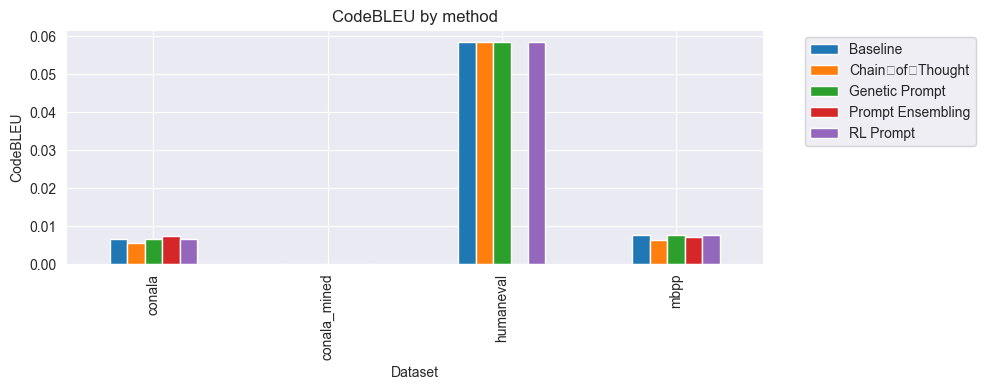

In [24]:
# 8  Bar‑plot (optional) -----------------------------------------
ax = df.pivot(index='Dataset', columns='Method', values='CodeBLEU').plot(
    kind='bar', figsize=(10,4), title='CodeBLEU by method')
ax.set_ylabel('CodeBLEU')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
